### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

In [29]:
from sklearn.preprocessing import MinMaxScaler

In [28]:
import warnings
warnings.filterwarnings('ignore')

### Step 2: Load Dataset

In [2]:
headers = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration","num-of-doors", "body-style","drive-wheels", "engine-location",
           "wheel-base","length", "width","height", "curb-weight", "engine-type","num-of-cylinders", "engine-size", "fuel-system","bore",
           "stroke", "compression-ratio", "horsepower", "peak-rpm","city-mpg","highway-mpg","price"]

In [3]:
df = pd.read_csv('./data/imports-85.data', names=headers)

In [4]:
df.shape

(205, 26)

In [5]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


### Step 3: Explore Data

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
symboling,205.0,0.834146,1.245307,-2.0,0.0,1.0,2.0,3.0
wheel-base,205.0,98.756585,6.021776,86.6,94.5,97.0,102.4,120.9
length,205.0,174.049268,12.337289,141.1,166.3,173.2,183.1,208.1
width,205.0,65.907805,2.145204,60.3,64.1,65.5,66.9,72.3
height,205.0,53.724878,2.443522,47.8,52.0,54.1,55.5,59.8
curb-weight,205.0,2555.565854,520.680204,1488.0,2145.0,2414.0,2935.0,4066.0
engine-size,205.0,126.907317,41.642693,61.0,97.0,120.0,141.0,326.0
compression-ratio,205.0,10.142537,3.972040,7.0,8.6,9.0,9.4,23.0
city-mpg,205.0,25.219512,6.542142,13.0,19.0,24.0,30.0,49.0
highway-mpg,205.0,30.751220,6.886443,16.0,25.0,30.0,34.0,54.0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [9]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

### Step 4: Feature Engineering

In [10]:
df['city-mpg'] = 235 / df['city-mpg']

In [13]:
df.rename(columns={'city-mpg': 'city-L/100km'}, inplace=True)

In [23]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [26]:
df.dropna(inplace=True)

In [30]:
scaler = MinMaxScaler()

In [34]:
cols = ['length', 'width', 'height']
for col in cols:
    df[col] = scaler.fit_transform(df[[col]])

In [39]:
bins = np.linspace(df['price'].min(), df['price'].max(), 4)

In [40]:
group_names = ['Low', 'Medium', 'High']

In [43]:
df['price-binned'] = pd.cut(
    df['price'],
    bins,
    labels=group_names,
    include_lowest=True
)

<Axes: xlabel='price-binned', ylabel='Count'>

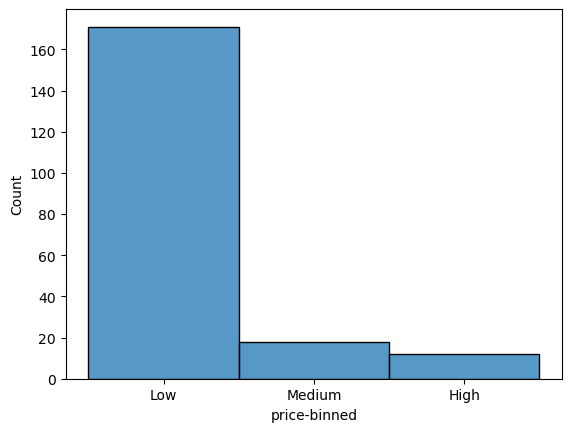

In [45]:
sns.histplot(df['price-binned'])

In [48]:
df['fuel-type'].unique()

array(['gas', 'diesel'], dtype=object)

In [54]:
df = pd.concat([df.drop('fuel-type', axis=1), pd.get_dummies(df['fuel-type'])], axis=1)

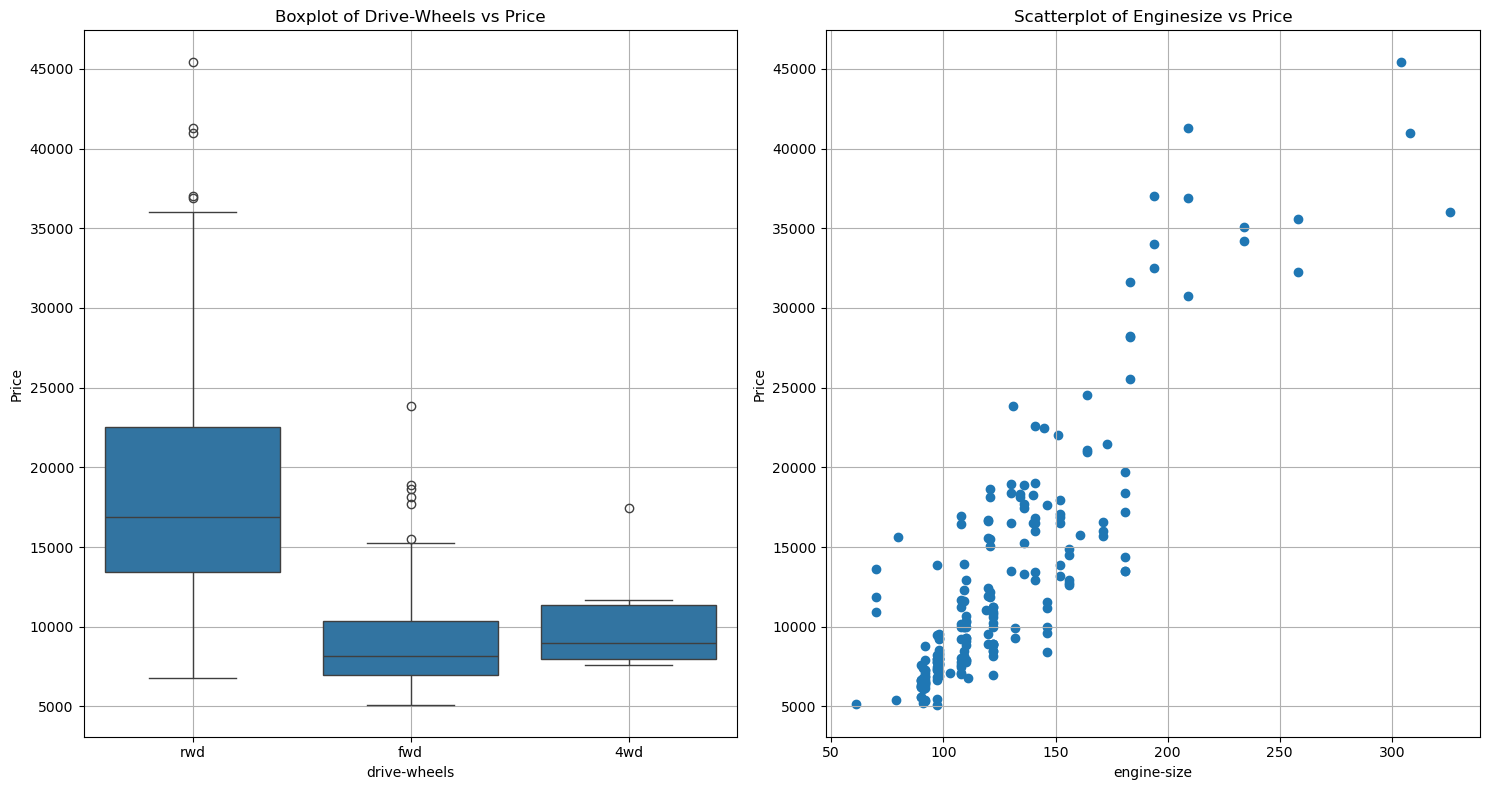

In [61]:
plt.figure(figsize=(15, 8))
plt.subplot(1, 2, 1)
sns.boxplot(x ='drive-wheels', y ='price', data = df)

plt.title('Boxplot of Drive-Wheels vs Price')
plt.xlabel('drive-wheels')
plt.ylabel('Price')
plt.grid()

plt.subplot(1, 2, 2)
plt.scatter(df['engine-size'], df['price'])
plt.title('Scatterplot of Enginesize vs Price')
plt.xlabel('engine-size')
plt.ylabel('Price')
plt.grid()

plt.tight_layout()

In [67]:
data_grp = df[['drive-wheels', 'body-style', 'price']].groupby(
    ['drive-wheels', 'body-style'], as_index = False
).mean()

In [70]:
data_pivot = data_grp.pivot(
    index='drive-wheels',
    columns='body-style'
)

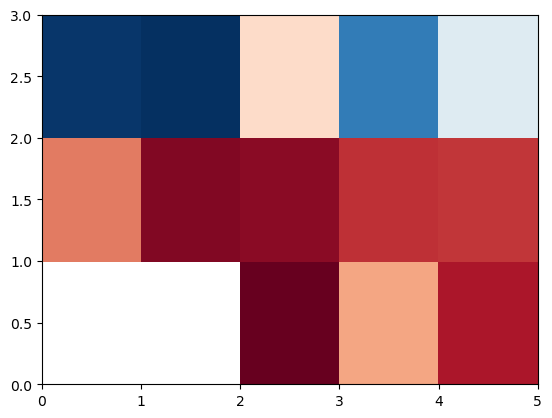

In [71]:
plt.pcolor(data_pivot, cmap=plt.cm.RdBu)

In [73]:
grouped_annova = df[['make', 'price']].groupby(['make'])

In [76]:
annova_results_l = sp.stats.f_oneway(
    grouped_annova.get_group('honda')['price'],
    grouped_annova.get_group('subaru')['price']
)

In [78]:
print(annova_results_l)

F_onewayResult(statistic=0.19744030127462606, pvalue=0.6609478240622193)


<Axes: xlabel='engine-size', ylabel='price'>

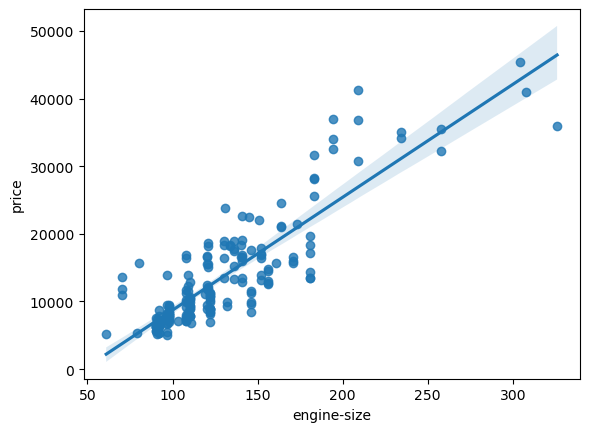

In [79]:
sns.regplot(x='engine-size', y='price', data=df)